In [1]:

# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "JaredLasley"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW4"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

* The primary objective of this experiment is to determine if there is a meanigful difference in 100-meter sprint between the Aerostep and Bionic-Flex prosthesis.
2.  Specify the outcome variable and how it is measured.
 * The outcome variable is Sprint_Time (Continuous Numeric Variable), the unit for Sprint_Time is seconds.
3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

* **Independent Variables**
  * Athlete_ID (nominal categorical variable)
  * Blade_Type (nominal categorical variable)
  * Trial (Ordinal Categorical Variable)

* **Lurking** = There could be a lurking variable if the wind speed changes notably between trials or athletes. It is standard practice to measure the wind velocity during professional to determine eligibility for record inclusion precisely because at this level of competition the direction and speed of the wind can have a pronounced effect on the outcome of a race.

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

* The primary difference between a random effect and a fixed effect is how we treat the levels of categorical variables under analysis. In fixed effect we are concerned with comparing the means of the response variable(Sprint_Time) across every level the categorical in question. While in contrast when exploring a random effect we are intrested in comparing only the variance of the levels as a whole.

  We must account for random effects in our design because if we included the individual levels of Athlete_ID and Trial as a fixed effects we would create an issue with indepence of errors as there is in inherent relationship between trials in longitudinal data.

5.  State the sets of null and alternative hypotheses for this experiment.

$$ \begin{align*} &H_{01}: \alpha_1 = \alpha_2  \\
                  &H_{11}: \alpha_1 \neq \alpha_2  \\
                  &H_{02}: \sigma^2_{Blade Type} = 0 \\
                  &H_{12}: \sigma^2_{Blade Type} > 0
   \end{align*}
   $$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

* Both the statistical exploratory data analysis and data visualizations more strongly support the alternative hypothesis. In the exploratory data analysis we can see that for every athlete the sprint time of the Aerostep prosthesis is lower than that of the of the Bionic-Flex by multiple standard deviations. Additionally on the side-by-side boxplots we can see that for each runner the top of the Aerostep box is lower than the bottom of tthe Bio-flex box. This suggests that there is a significant difference in the mean sprint time of each prosthesis thus supporting the alternative hypothesis.

  Athlete_ID   Blade_Type  Trial  Sprint_Time
0  Athlete_1     Aerostep      1        11.63
1  Athlete_1     Aerostep      2        11.57
2  Athlete_1     Aerostep      3        11.39
3  Athlete_1  Bionic-Flex      1        11.74
4  Athlete_1  Bionic-Flex      2        11.68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None
  Athlete_ID   Blade_Type       mean       std
0  Athlete_1     Aerostep  11.530000  0.124900
1  Athlete_1  Bionic-Flex  11.703333  0.032146
2  Athlete_2     Aerostep  10.960000  0.034641
3  Athlete_2  Bionic-Flex  11.133333  0.051316
4  Athlete_3     Aerostep  11.273333  0.032146
5  Athlete_3  Bionic-

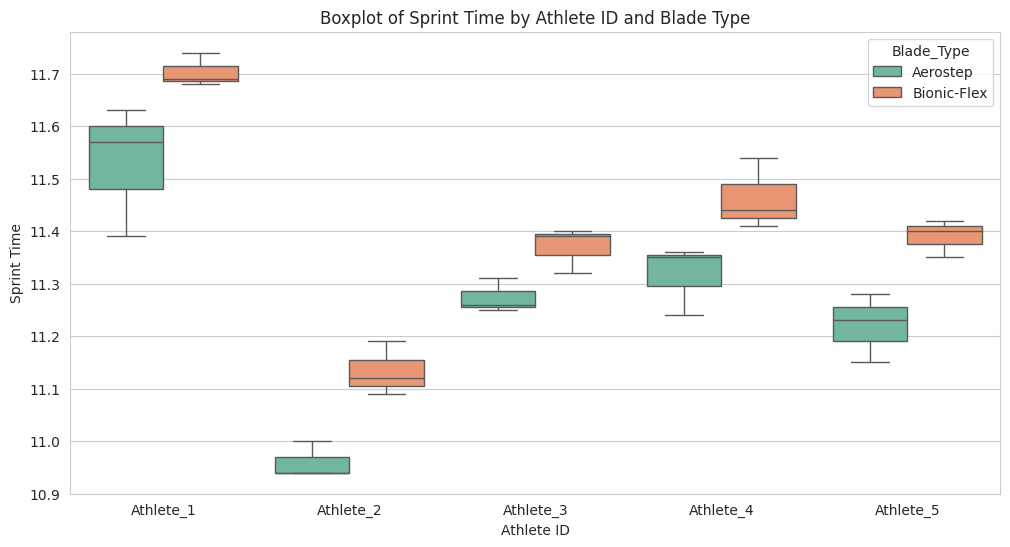

In [8]:
## Import Libraries ##
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols, mixedlm
from scipy import stats
from scipy.stats import chi2 # Import chi2
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns
## Import the Data ##

race = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

## Evaluate Data Integrity ##

print(race.head())
print(race.info())

## Run Exploratory Data Analysis ##

## Calculate Means and SDs by Athlere_ID and Blade_Type ##

Athlete_ID_Blade_Type_stats = race.groupby(['Athlete_ID', 'Blade_Type'])['Sprint_Time'].agg(['mean', 'std']).reset_index()
print(Athlete_ID_Blade_Type_stats)

## Visualize Data using Boxplots ##

sns.set_style("whitegrid") # Use a clean background
plt.figure(figsize=(12, 6))
sns.boxplot(x='Athlete_ID', y='Sprint_Time', hue='Blade_Type', data=race, palette='Set2')
plt.title('Boxplot of Sprint Time by Athlete ID and Blade Type')
plt.xlabel('Athlete ID')
plt.ylabel('Sprint Time')
plt.legend(title='Blade_Type')
plt.show()

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

* Both the QQ plot and the Shapiro-Wilk more strongly support the assumption of normality. In the QQ plot the data points remains coincided with 45 degree line with the only notable exception being the data point at the far left edge of the plot. In addition to the visual evidence the Shapiro-Wilk test fails to reject with a p-value of 0.31, further supporting the assumption of normality.

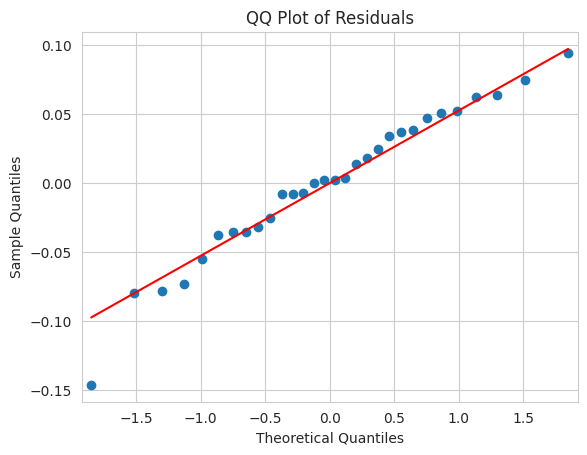

Shapiro-Wilk Test Statistic: 0.9713
Shapiro-Wilk Test P-Value: 0.5746
Fail to reject null hypothesis: Residuals are normally distributed.


In [30]:
## Fit the Full Mixed Effects Model ##

mixed_mod = mixedlm("Sprint_Time~Blade_Type",data=race, groups=race["Athlete_ID"])
mixed_result = mixed_mod.fit(reml=False,method='nm') # Fit using ML for comparison

## Fit the Reduced Model (Note this is keeping the fixed effect) ##

reduced_mod = ols('Sprint_Time ~ Blade_Type', data=race).fit()

## Extract Model Residuals ##

residuals = mixed_result.resid


## Generate QQ plot using seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

#Inferential Testing

## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

* Both the box plots and the Breusch-Pagan test more strongly support the assumption of homoscedasticity. The boxplots are both centered around 0 and overlap almost completetly. Additionally the B-P test returns a p-value of 0.48 which fails to reject the null hypothesis, thus supporting the assumption of homoscedasticity.

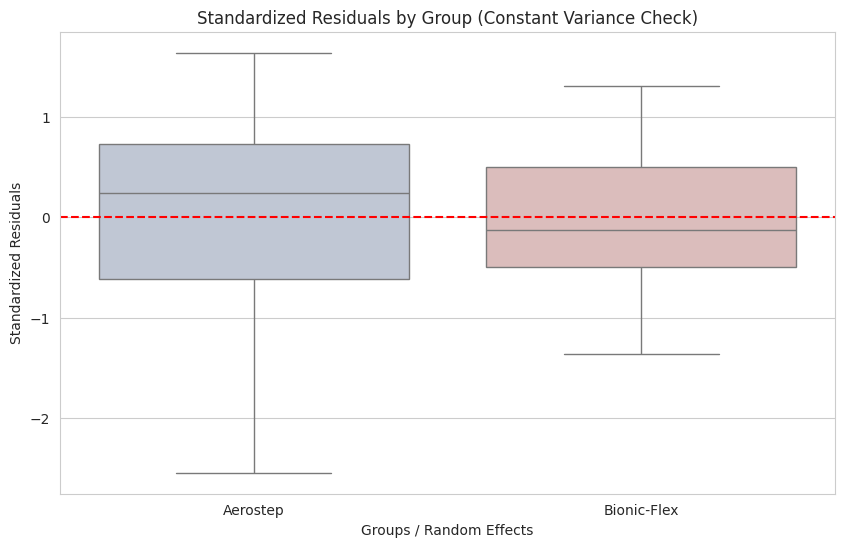

BP Test F-statistic: 1.758774701035814
BP Test F p-value: 0.19549437688748963
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [31]:
## Obtain Standardized Residuals ##

# The get_influence() method is not available for MixedLMResults.
# Standardized residuals can be calculated by dividing raw residuals by the estimated standard deviation of the error term.
standardized_residuals = mixed_result.resid / np.sqrt(mixed_result.scale)

# Create a temporary DataFrame for plotting standardized residuals by Blade_Type
plot_data = pd.DataFrame({'Blade_Type': race['Blade_Type'], 'standardized_residuals': standardized_residuals})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Blade_Type', y='standardized_residuals', data=plot_data, hue='Blade_Type', palette='vlag', legend=False)
plt.axhline(0, color='red', linestyle='--') # Baseline

plt.title('Standardized Residuals by Group (Constant Variance Check)')
plt.xlabel('Groups / Random Effects')
plt.ylabel('Standardized Residuals')
plt.show()


#Inferential Testing of Homoscedasticity

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(mixed_result.resid,mixed_result.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?


* The likelihood ratio test statistic of 51.19 produces a p-value < 0.001 which leads us to reject the null hypothesis. The data more strongly supports the altervative hypothesis. The variance in sprint times due to blade type is greater than 0.


In [32]:
## Perform Likelihood Ratio Test ##

ll_full = mixed_result.llf
ll_reduced = reduced_mod.llf

LR_stat = 2 * (ll_full - ll_reduced)
p_value = 0.5 * (1 - chi2.cdf(LR_stat, df=1))
print(f"Likelihood Ratio Test Statistic: {LR_stat}, p-value: {p_value}")


Likelihood Ratio Test Statistic: 51.1890964501146, p-value: 4.1944225870338414e-13


10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

*  From the summary of the fixed effect categories we find a z-score of 7.2 with a p-value equal to 0 for the Bionic-Flex level of blade_type. It follows then that we reject the null hypothesis. The data more strongly supports the alternative hypothesis. This suggests there is a signifigant difference in sprint_time between blade_type levels.


In [33]:
print(mixed_result.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 ML         
No. Groups:           5           Scale:                  0.0033     
Min. group size:      6           Log-Likelihood:         32.8616    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.082 136.819 0.000 11.099 11.421
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.241 0.000  0.111  0.193
Group Var                  0.033    0.401                            



11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

* In conclusion there is a statisticaly significant difference between the two types of prostheses being tested. Every athlete performed better when using the Bio-flex blade type as opposed to the Aerostep. Limitations of this experiment include a small sample size of athletes tested. In the future this experiment could be improved upon by increasing the number of participants to create more robust conclusions. Additionally, more blade types should be tested in order to establish a comprehensive basline perfomace metric to compare new blade types against and ensure fair and equitable competition.